In [5]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# make_blobs : Generate synthetic dataset with 3 clusters: 500 data point, 3 cluster, cluster standard deviation
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [ ]:
# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [7]:
# Scale the features (important for clustering algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

+ 1. K MEANS CLUSTERING

In [10]:
# Elbow method: calculate inertia for different k values
inertia = [] # WCSS value 
K_range = range(1, 11) # test 1 to 11 clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42) # using kmeans clustering to create the clusters
    kmeans.fit(X_scaled) # the dataframe we have
    inertia.append(kmeans.inertia_) # save the wcss value from the k means
inertia

[1000.0,
 528.8064432605652,
 294.437706867819,
 250.45524696534466,
 216.88110656982616,
 185.27440675195916,
 156.70879996290458,
 135.62603453115258,
 129.10396348239817,
 119.94101297104999]

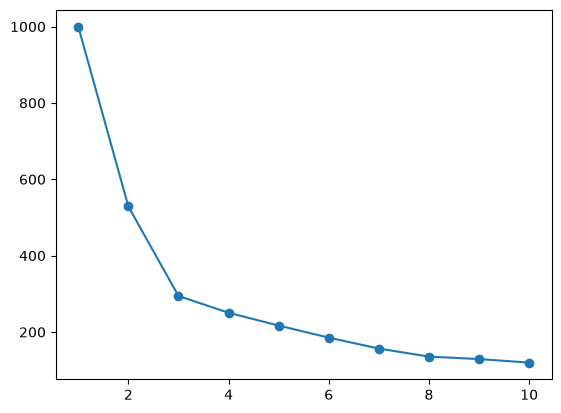

In [11]:
# Plot inertia vs number of clusters to find the "elbow"
plt.plot(K_range, inertia, marker='o') # visulaize the k range for inertia with a marker

In [ ]:
# Final KMeans model with 3 clusters: we get to know from the above figure
kmeans_final = KMeans(n_clusters=3, random_state=42) # creatae the final 
cluster_labels = kmeans_final.fit_predict(X_scaled) # plot the labels to the final k means

In [13]:
df['cluster'] = cluster_labels


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

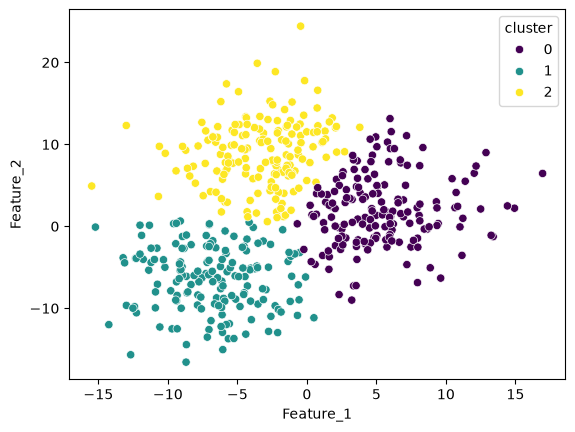

In [14]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

+ 2. DB SCAN ALGORITHM

In [15]:
# Generate a non-linear dataset (moons) to test clustering
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [16]:
# Create DataFrame
from sklearn.cluster import KMeans, DBSCAN
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [17]:

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [18]:
# Apply KMeans (works poorly on non-linear data like moons)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

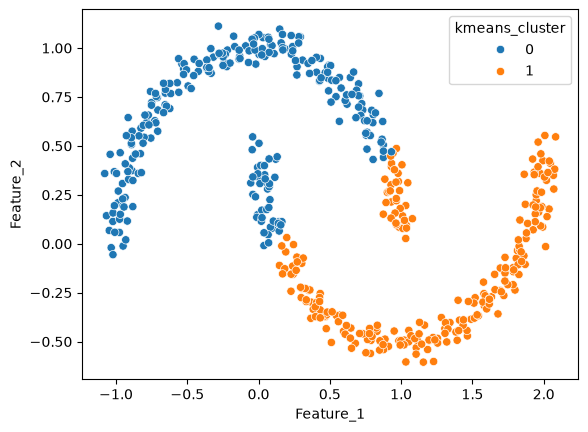

In [19]:
# Visualize KMeans clusters
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

*APPLY THE DB SCAN FOR THIS NON LINER DATA*

In [20]:
# Apply DBSCAN (better for non-linear shapes)
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

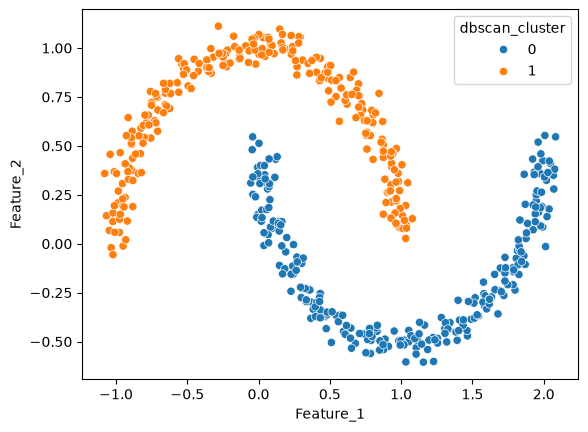

In [21]:
# Visualize DBSCAN clusters
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')